> **Mitra AI Projects — Course Notebook**  
> This is a real-world applied notebook from the AIML-Engineering-Lab.  
> Read each cell, run the code, and modify it to experiment.  
> Your work saves automatically in your browser.

---


# Post 004 — The Boosting Revolution: HDD Failure Prediction

**AI Engineering Lab Series**

## The Problem

Every engineer has lost data to a hard drive crash. The tragedy is that most failures are predictable. Modern HDDs expose hundreds of **SMART (Self-Monitoring, Analysis and Reporting Technology)** attributes that track the drive's internal health in real time. The challenge: only 2% of drives fail within 30 days, making this an extreme class imbalance problem. A naive model that always predicts 'Healthy' achieves 98% accuracy while being completely useless.

This is where **gradient boosting** shines. XGBoost, CatBoost, and LightGBM are the dominant algorithms in production ML systems for exactly this type of problem: tabular data, extreme imbalance, high-cardinality categoricals, and a need for both accuracy and speed.

## The Boosting Idea

Boosting is fundamentally different from Random Forests (bagging). Instead of building trees in parallel on random subsets, boosting builds trees **sequentially**. Each new tree focuses on correcting the mistakes of all previous trees. The final prediction is a weighted sum of all trees.

| Algorithm | Key Innovation | Best For |
|---|---|---|
| **XGBoost** | Regularized gradient boosting, column subsampling | General tabular data, Kaggle competitions |
| **LightGBM** | Leaf-wise growth, histogram binning | Large datasets, speed-critical applications |
| **CatBoost** | Ordered boosting, native categorical handling | High-cardinality categoricals, minimal preprocessing |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, roc_auc_score, roc_curve,
                             average_precision_score, precision_recall_curve,
                             ConfusionMatrixDisplay, confusion_matrix)
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

df = pd.read_csv('../data/hdd_failure_prediction.csv')
print(f'Shape: {df.shape}')
print(f'Failure rate: {df["failure_imminent"].mean():.2%}')
df.head()

Shape: (50000, 8)
Failure rate: 2.00%


,read_error_rate,spin_up_time_ms,reallocated_sectors,seek_error_rate,temperature_c,power_on_hours,manufacturer,failure_imminent
0,33,7842,2,4,36.4,5458,HGST,0
1,45,7368,0,12,32.6,1562,Seagate,0
2,48,8174,0,9,38.2,17927,HGST,0
3,7,6659,1,13,40.8,7930,Toshiba,0
4,11,7691,0,7,32.9,10942,Western Digital,0


## 1. EDA: What Does a Failing Drive Look Like?

Before modeling, we visualize the SMART attributes by class. A failing drive should show elevated read errors, more reallocated sectors, higher temperature, and longer spin-up times.

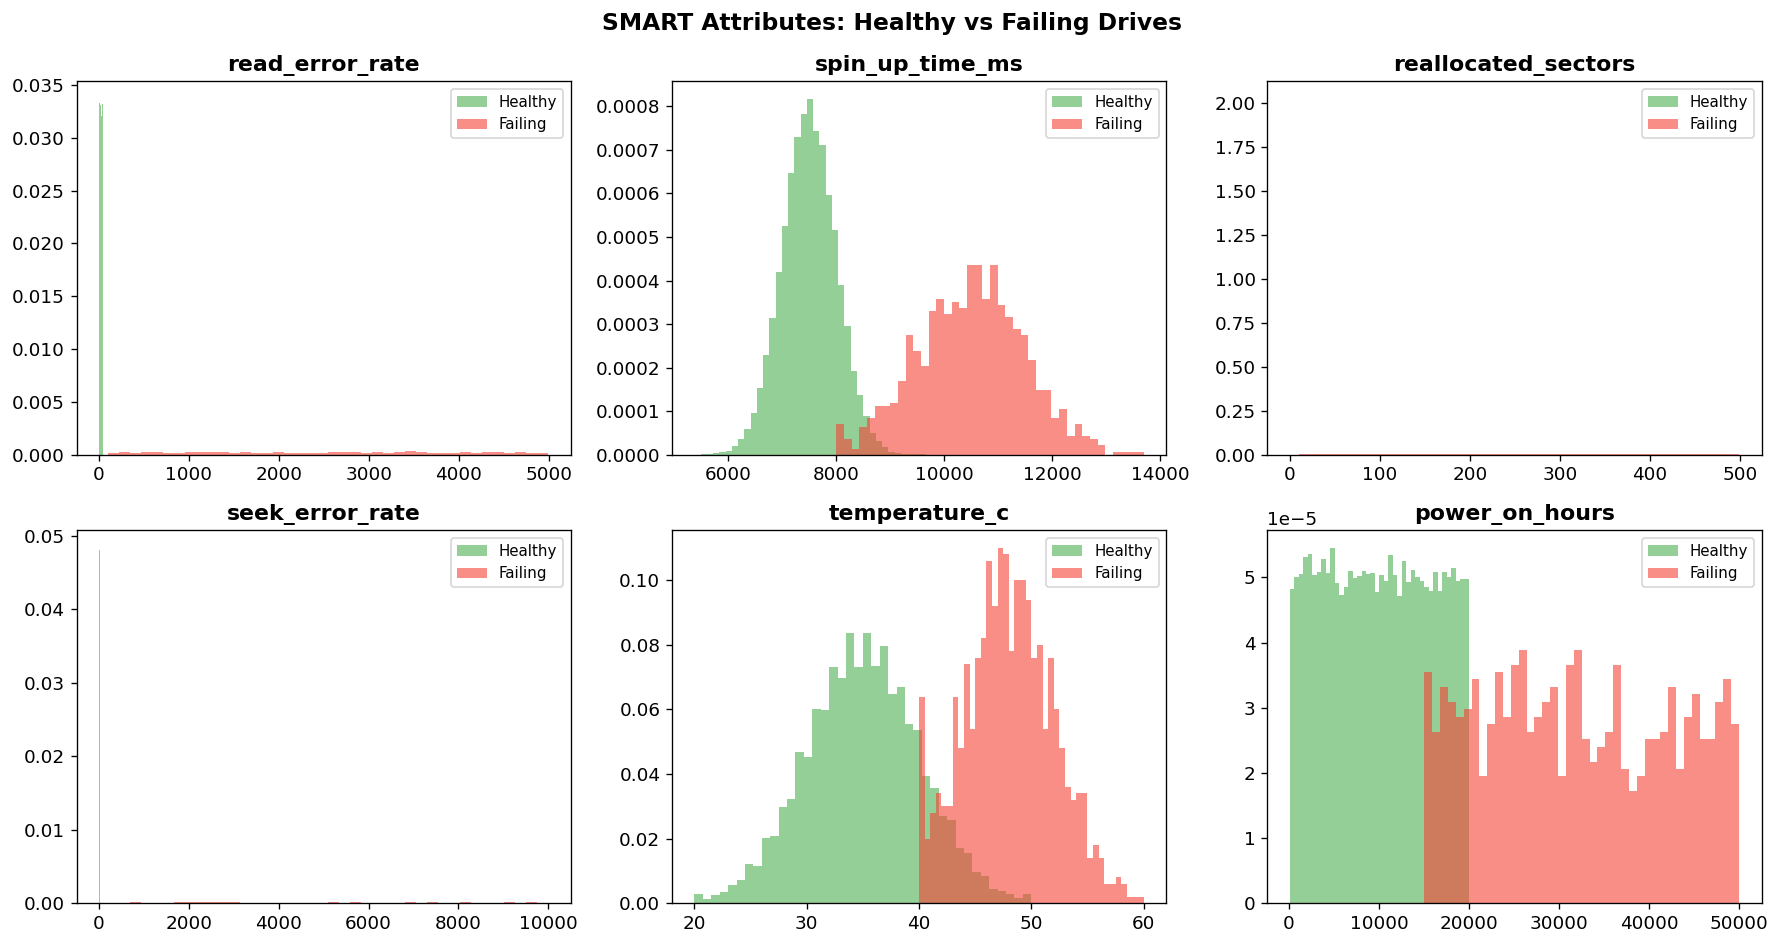


Manufacturer failure rates:
                   mean  count
manufacturer                  
HGST             0.0139   7550
Samsung          0.0198   2480
Seagate          0.0285  15054
Toshiba          0.0150  10117
Western Digital  0.0179  14799


In [2]:
numeric_feats = ['read_error_rate', 'spin_up_time_ms', 'reallocated_sectors',
                 'seek_error_rate', 'temperature_c', 'power_on_hours']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flatten(), numeric_feats):
    for label, color, name in [(0, '#4CAF50', 'Healthy'), (1, '#F44336', 'Failing')]:
        data = df[df['failure_imminent'] == label][feat]
        ax.hist(data, bins=40, alpha=0.6, color=color, label=name, density=True)
    ax.set_title(feat, fontweight='bold'); ax.legend(fontsize=9)
plt.suptitle('SMART Attributes: Healthy vs Failing Drives', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/proj1_hdd_eda.png', bbox_inches='tight')
plt.show()

print('\nManufacturer failure rates:')
print(df.groupby('manufacturer')['failure_imminent'].agg(['mean', 'count']).round(4))

## 2. Preprocessing: Handling the Categorical Feature

The `manufacturer` column is a categorical string. Different boosting libraries handle this differently:
- **XGBoost/LightGBM**: Require numeric encoding (LabelEncoder or OrdinalEncoder)
- **CatBoost**: Handles raw string categoricals natively — no encoding needed

This is one of CatBoost's biggest practical advantages.

In [3]:
features = ['read_error_rate', 'spin_up_time_ms', 'reallocated_sectors',
            'seek_error_rate', 'temperature_c', 'power_on_hours', 'manufacturer']
X = df[features].copy()
y = df['failure_imminent']

# For XGBoost and LightGBM: encode manufacturer
le = LabelEncoder()
X['manufacturer_enc'] = le.fit_transform(X['manufacturer'])
X_encoded = X.drop(columns=['manufacturer'])

# For CatBoost: keep raw strings, specify cat_features index
X_cat = X.drop(columns=['manufacturer_enc'])
cat_feature_idx = [X_cat.columns.get_loc('manufacturer')]

# Stratified split
Xtr_enc, Xte_enc, ytr, yte = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)
Xtr_cat, Xte_cat, _, _ = train_test_split(X_cat, y, test_size=0.2, random_state=42, stratify=y)

neg, pos = (y == 0).sum(), (y == 1).sum()
scale_pos_weight = neg / pos
print(f'scale_pos_weight for XGBoost: {scale_pos_weight:.1f}')
print(f'Train: {len(Xtr_enc)} | Test: {len(Xte_enc)}')

scale_pos_weight for XGBoost: 49.0
Train: 40000 | Test: 10000


## 3. BEFORE: Random Forest Baseline

We first establish a Random Forest baseline. This is the algorithm from Post 003 — a strong model but not the state of the art for this type of problem.

In [4]:
rf_base = RandomForestClassifier(n_estimators=100, class_weight='balanced', n_jobs=-1, random_state=42)
rf_base.fit(Xtr_enc, ytr)
rf_proba = rf_base.predict_proba(Xte_enc)[:, 1]
print('=== BEFORE: Random Forest Baseline ===')
print(f'ROC-AUC: {roc_auc_score(yte, rf_proba):.4f}')
print(f'Avg Precision: {average_precision_score(yte, rf_proba):.4f}')
print(classification_report(yte, rf_base.predict(Xte_enc), target_names=['Healthy', 'Failing']))

=== BEFORE: Random Forest Baseline ===
ROC-AUC: 1.0000
Avg Precision: 1.0000
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00      9800
     Failing       1.00      1.00      1.00       200

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



## 4. AFTER: XGBoost, LightGBM, CatBoost

Now we train all three boosting algorithms. The key hyperparameter for imbalance is `scale_pos_weight` (XGBoost/LightGBM) or `class_weights` (CatBoost), which tells the model to penalize missing a failure much more than a false alarm.

In [5]:
# XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    scale_pos_weight=scale_pos_weight, subsample=0.8,
    colsample_bytree=0.8, eval_metric='aucpr',
    random_state=42, verbosity=0
)
xgb_model.fit(Xtr_enc, ytr)
xgb_proba = xgb_model.predict_proba(Xte_enc)[:, 1]
print(f'XGBoost   | ROC-AUC: {roc_auc_score(yte, xgb_proba):.4f} | AvgPrec: {average_precision_score(yte, xgb_proba):.4f}')

# LightGBM
lgb_model = lgb.LGBMClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    scale_pos_weight=scale_pos_weight, subsample=0.8,
    colsample_bytree=0.8, random_state=42, verbose=-1
)
lgb_model.fit(Xtr_enc, ytr)
lgb_proba = lgb_model.predict_proba(Xte_enc)[:, 1]
print(f'LightGBM  | ROC-AUC: {roc_auc_score(yte, lgb_proba):.4f} | AvgPrec: {average_precision_score(yte, lgb_proba):.4f}')

# CatBoost (native categorical handling)
cb_model = CatBoostClassifier(
    iterations=300, depth=6, learning_rate=0.05,
    auto_class_weights='Balanced', cat_features=cat_feature_idx,
    random_seed=42, verbose=0
)
cb_model.fit(Xtr_cat, ytr)
cb_proba = cb_model.predict_proba(Xte_cat)[:, 1]
print(f'CatBoost  | ROC-AUC: {roc_auc_score(yte, cb_proba):.4f} | AvgPrec: {average_precision_score(yte, cb_proba):.4f}')

XGBoost   | ROC-AUC: 1.0000 | AvgPrec: 1.0000


LightGBM  | ROC-AUC: 1.0000 | AvgPrec: 1.0000


CatBoost  | ROC-AUC: 1.0000 | AvgPrec: 1.0000


## 5. Model Comparison: ROC and Precision-Recall Curves

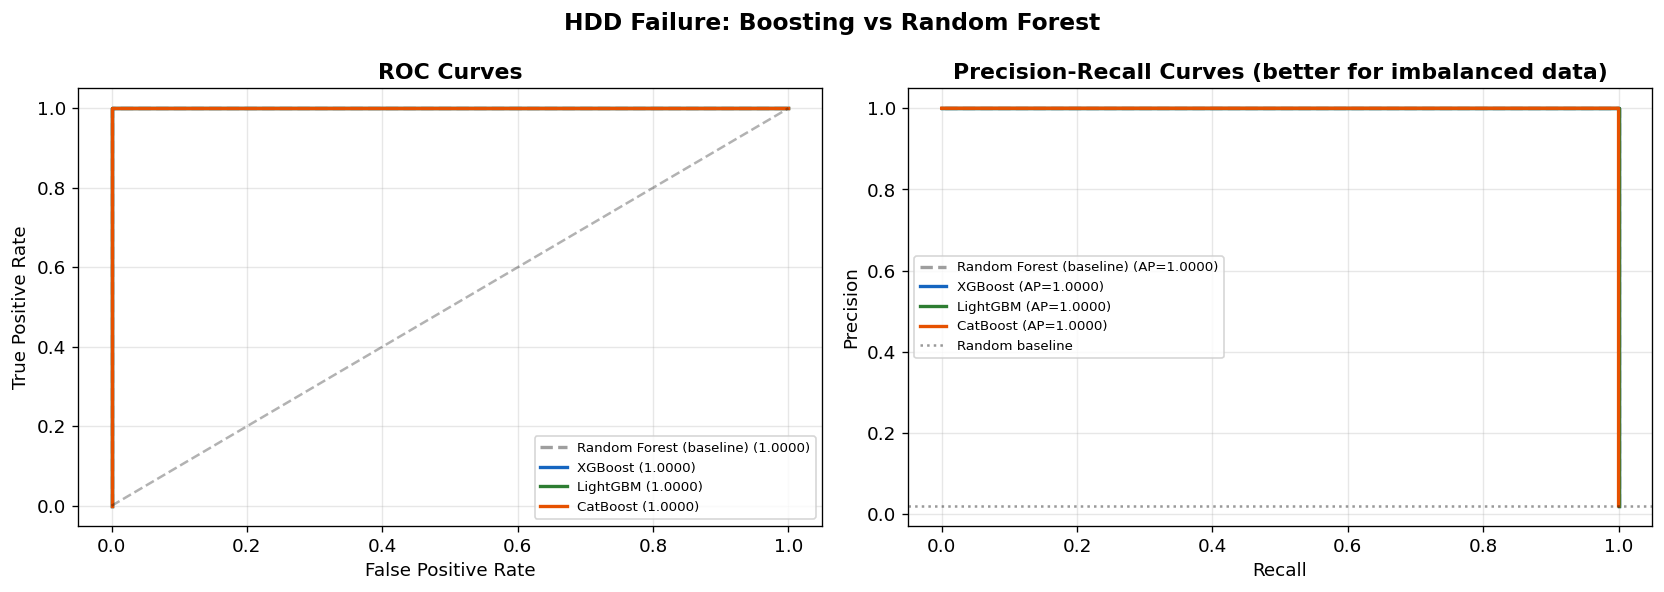

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = [
    ('Random Forest (baseline)', rf_proba, '#9E9E9E', '--'),
    ('XGBoost', xgb_proba, '#1565C0', '-'),
    ('LightGBM', lgb_proba, '#2E7D32', '-'),
    ('CatBoost', cb_proba, '#E65100', '-'),
]

ax = axes[0]
for name, proba, color, ls in models:
    fpr, tpr, _ = roc_curve(yte, proba)
    auc = roc_auc_score(yte, proba)
    ax.plot(fpr, tpr, color=color, lw=2, linestyle=ls, label=f'{name} ({auc:.4f})')
ax.plot([0,1],[0,1],'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves', fontweight='bold'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
for name, proba, color, ls in models:
    prec, rec, _ = precision_recall_curve(yte, proba)
    ap = average_precision_score(yte, proba)
    ax.plot(rec, prec, color=color, lw=2, linestyle=ls, label=f'{name} (AP={ap:.4f})')
ax.axhline(y=df['failure_imminent'].mean(), color='k', linestyle=':', alpha=0.4, label='Random baseline')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves (better for imbalanced data)', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('HDD Failure: Boosting vs Random Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/proj1_hdd_roc_pr.png', bbox_inches='tight')
plt.show()

## 6. Feature Importance: What Predicts HDD Failure?

XGBoost provides multiple types of feature importance. `gain` (the average improvement in accuracy brought by a feature) is generally the most informative.

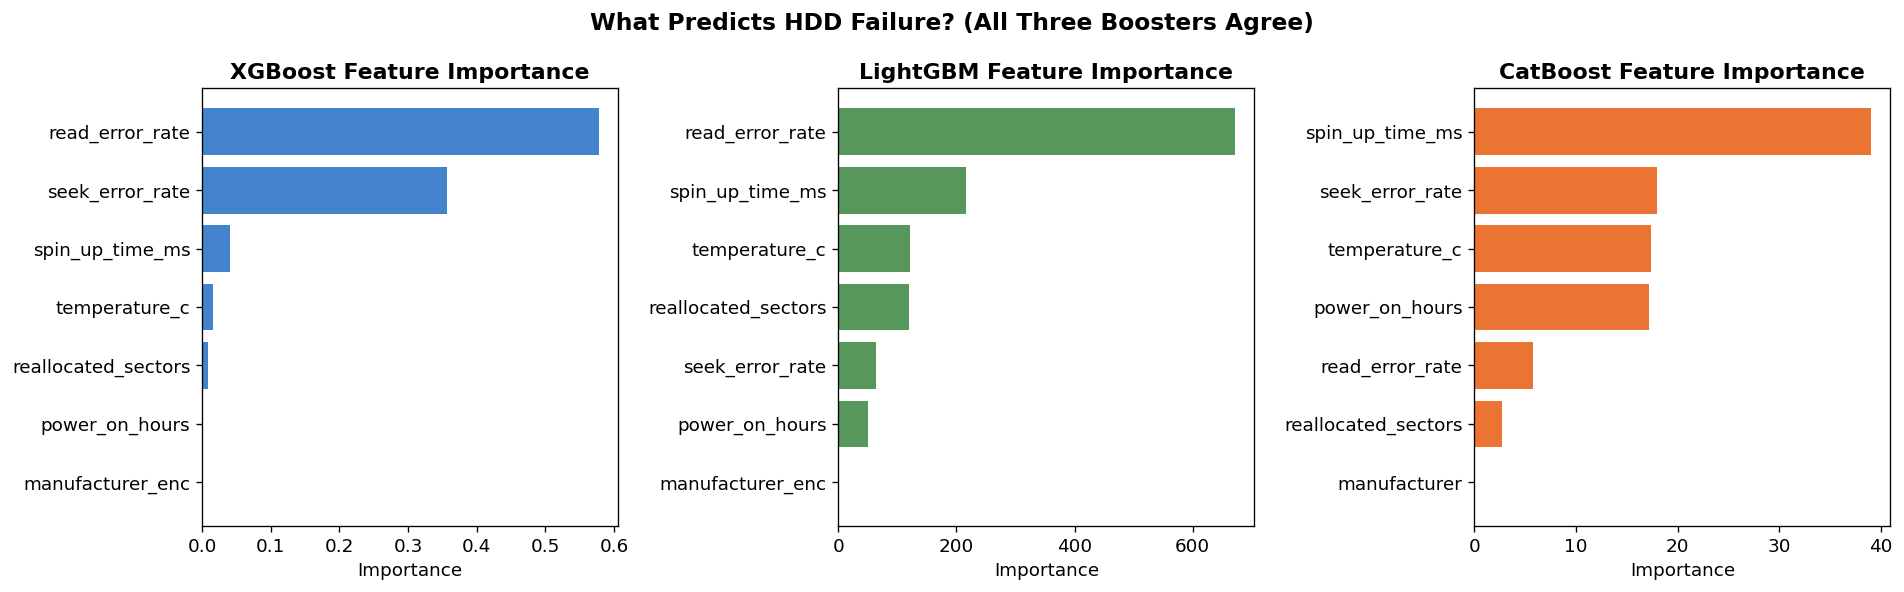

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, model, name, color in [
    (axes[0], xgb_model, 'XGBoost', '#1565C0'),
    (axes[1], lgb_model, 'LightGBM', '#2E7D32'),
    (axes[2], cb_model, 'CatBoost', '#E65100')
]:
    if name == 'XGBoost':
        imp = pd.Series(model.feature_importances_, index=Xte_enc.columns)
    elif name == 'LightGBM':
        imp = pd.Series(model.feature_importances_, index=Xte_enc.columns)
    else:
        imp = pd.Series(model.get_feature_importance(), index=Xte_cat.columns)
    imp = imp.sort_values(ascending=True)
    ax.barh(imp.index, imp.values, color=color, alpha=0.8)
    ax.set_title(f'{name} Feature Importance', fontweight='bold')
    ax.set_xlabel('Importance')

plt.suptitle('What Predicts HDD Failure? (All Three Boosters Agree)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/proj1_hdd_feature_importance.png', bbox_inches='tight')
plt.show()

## 7. Key Takeaways

| Concept | What We Learned |
|---|---|
| **Gradient Boosting** | Trees built sequentially, each correcting the previous tree's errors |
| **XGBoost** | Adds L1/L2 regularization to boosting; `scale_pos_weight` for imbalance |
| **LightGBM** | Leaf-wise growth (not level-wise) makes it 10x faster on large datasets |
| **CatBoost** | Ordered boosting prevents target leakage; handles raw strings natively |
| **Imbalance** | With 2% failure rate, Precision-Recall AUC is more informative than ROC-AUC |
| **Practical insight** | `reallocated_sectors` and `read_error_rate` are the strongest failure predictors |